# 02 - Exploratory Data Analysis Old

This notebook now loads already-downloaded raw data from `data/raw` instead of downloading from Kaggle.

## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import linregress

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from datathon_2026_r1.eda import (
    load_all_tables,
    table_summary,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

PLOT_RCPARAMS = {
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "patch.edgecolor": "white",
    "patch.linewidth": 0.5,
}
plt.rcParams.update(PLOT_RCPARAMS)
sns.set_theme(style="whitegrid", palette="Set2", rc=PLOT_RCPARAMS)


## Load Raw Tables

In [2]:
tables = load_all_tables()

products = tables["products"]
orders = tables["orders"]
order_items = tables["order_items"]
promotions = tables["promotions"]
returns = tables["returns"]
sales = tables["sales"]
web_traffic = tables["web_traffic"]
inventory = tables["inventory"]
customers = tables["customers"]
geography = tables["geography"]
payments = tables["payments"]
shipments = tables["shipments"]
reviews = tables["reviews"]
sample_submission = tables["sample_submission"]

table_summary(tables)


,table,rows,columns,missing_cells,missing_pct,duplicate_rows,memory_mb
0,order_items,714669,7,1152816,0.2304,0,78.0027
1,orders,646945,8,0,0.0000,0,162.7759
2,payments,646945,4,0,0.0000,0,50.5635
3,shipments,566067,4,0,0.0000,0,17.2751
4,customers,121930,7,0,0.0000,0,29.0492
5,reviews,113551,7,0,0.0000,0,17.7564
6,inventory,60247,17,0,0.0000,0,16.7565
7,geography,39948,4,0,0.0000,0,6.8635
8,returns,39939,7,0,0.0000,0,6.0754
9,sales,3833,3,0,0.0000,0,0.0879


In [3]:
print("\nChecking data quality:")
pk_checks = {
    'products': products['product_id'].is_unique,
    'orders': orders['order_id'].is_unique,
    'promotions': promotions['promo_id'].is_unique
}
print("Primary Key Uniqueness:", pk_checks)

# Constraint: cogs < price (1.3.1)
invalid_cogs = products[products['cogs'] >= products['price']]
print(f"Number of product violate constraint COGS < Price: {len(invalid_cogs)}")


Checking data quality:
Primary Key Uniqueness: {'products': True, 'orders': True, 'promotions': True}
Number of product violate constraint COGS < Price: 0



T-test Margin (Premium vs Standard): p-value = 4.0246e-02
- Insight:There is a statistically significant difference in profit margins between the two segments.


C:\Users\BBQ\AppData\Local\Temp\ipykernel_21736\2397791418.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=products, x='segment', y='gross_margin', palette='Set2')


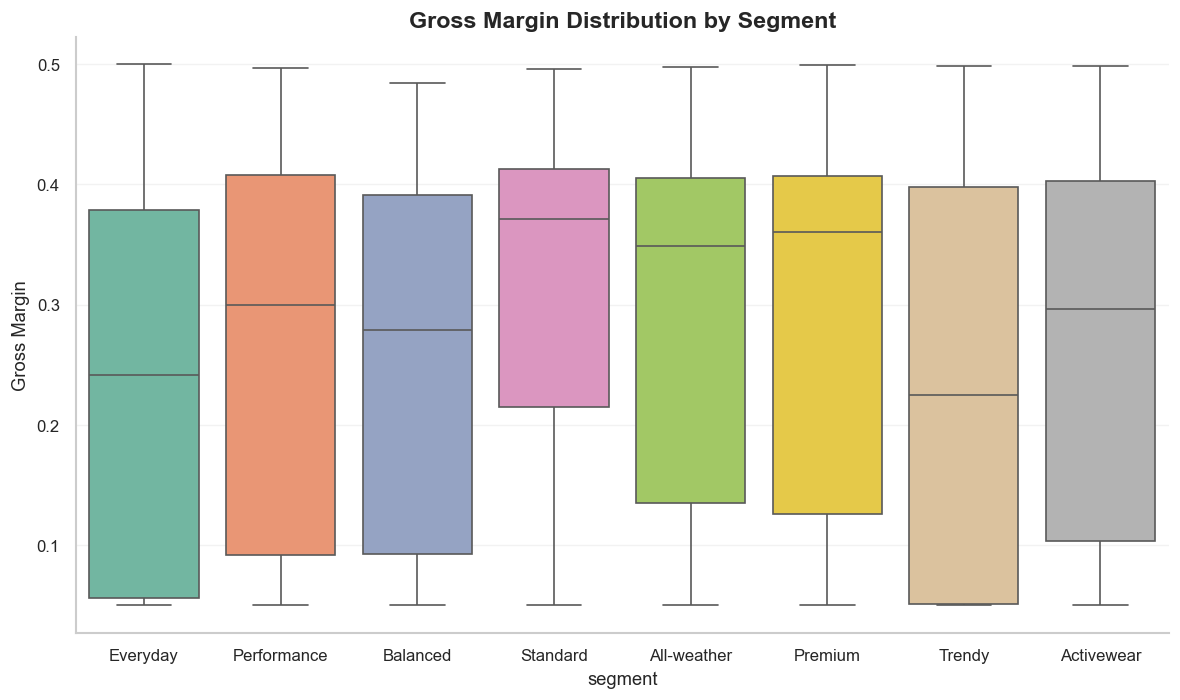

In [4]:
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']

plt.figure(figsize=(10, 6))
sns.boxplot(data=products, x='segment', y='gross_margin', palette='Set2')
plt.title('Gross Margin Distribution by Segment')
plt.ylabel('Gross Margin')
plt.tight_layout()

#  T-test between the two segments with the highest and lowest margins.
premium_margin = products[products['segment'] == 'Premium']['gross_margin']
standard_margin = products[products['segment'] == 'Standard']['gross_margin']
t_stat, p_val = stats.ttest_ind(premium_margin.dropna(), standard_margin.dropna())
print(f"\nT-test Margin (Premium vs Standard): p-value = {p_val:.4e}")
if p_val < 0.05:
    print("- Insight:There is a statistically significant difference in profit margins between the two segments.")

T-test cho 2 mẫu đọc lập: Gross Margin của standard và premium

Phát biểu giả thuyết:

$H_0$ (Giả thuyết không): Không có sự khác biệt về trung bình biên lợi nhuận (Gross Margin) giữa phân khúc Standard và Premium.

$H_1$ (Giả thuyết đối): Có sự khác biệt thực sự về trung bình biên lợi nhuận giữa hai phân khúc này.
$p_value$ = 0.0402.

Vì $0.0402 < 0.05$ ($\alpha$), chúng ta bác bỏ giả thuyết $H_0$.

Ý nghĩa: Chỉ có khoảng 4% xác suất sự chênh lệch này xảy ra do ngẫu nhiên. Do đó, ta có đủ cơ sở thống kê để kết luận rằng: Biên lợi nhuận gộp của phân khúc Standard và Premium là khác biệt nhau một cách thực sự (và dựa trên biểu đồ, Standard đang có tỷ suất lợi nhuận trung bình tốt hơn).

$\rightarrow$ Phân khúc Standard mới là nhóm duy trì tỷ suất lợi nhuận gộp trung bình cao và có độ phân tán ổn định hơn hẳn so với Premium (suy ra từ ý nghĩ phân khúc premium mới cho ra lợi nhuận cao).

In [5]:
oi_promo = order_items.merge(promotions, on='promo_id', how='left')
promo_usage = oi_promo['promo_id'].notna().mean() * 100
print(f"\n Percentage of products sold that included promotions: {promo_usage:.2f}%")


 Percentage of products sold that included promotions: 38.66%


return_reason
wrong_size          13967
defective            8020
not_as_described     7035
changed_mind         6931
late_delivery        3986
Name: count, dtype: int64


C:\Users\BBQ\AppData\Local\Temp\ipykernel_21736\1145830100.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=returns, y='return_reason', order=returns['return_reason'].value_counts().index, palette='viridis')


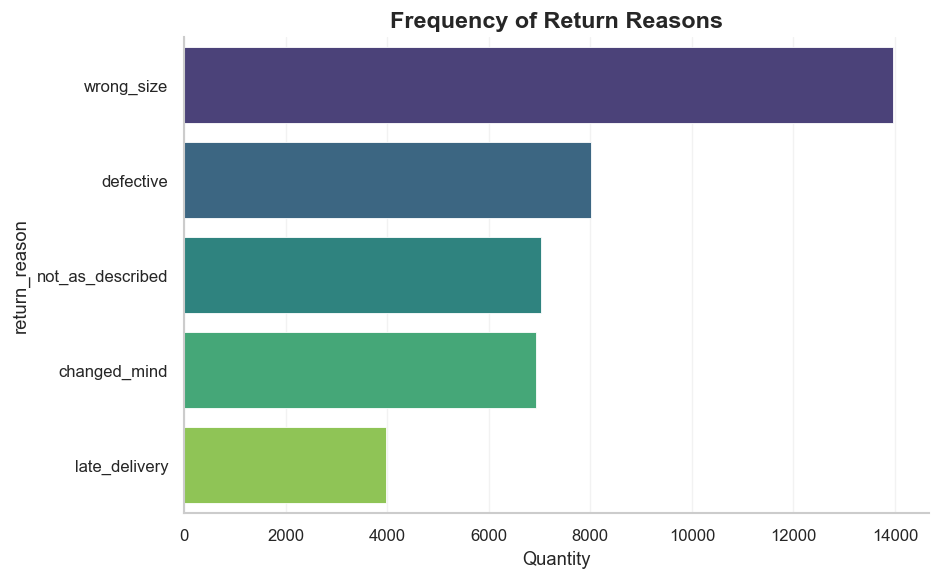

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=returns, y='return_reason', order=returns['return_reason'].value_counts().index, palette='viridis')
plt.title('Frequency of Return Reasons')
plt.xlabel('Quantity')
plt.tight_layout()
print(returns['return_reason'].value_counts())

Phân tích mô tả:
- wrong_size (sai kích cỡ) áp đảo hoàn toàn với khoảng 13967 lượt trả hàng, cao gần gấp đôi lý do xếp thứ hai (defective).

- defective (hàng lỗi) và not_as_described (không giống mô tả) lần lượt bám sát với khoảng 8020 và 7035 lượt.

- changed_mind (đổi ý) và late_delivery (giao trễ) chiếm tỷ trọng thấp hơn, trong đó giao hàng trễ ít bị phàn nàn nhất (khoảng 3986 lượt).

Dự đoán nguyên nhân xảy ra:
- Tỷ lệ wrong_size cao bất thường cho thấy bảng quy đổi kích cỡ (Size Guide) hiện tại có thể đang thiếu chuẩn xác hoặc form dáng sản phẩm không nhất quán giữa các thương hiệu/phân khúc.

- Lượng lớn hàng defective và not_as_described gộp lại (hơn 15055 lượt) báo hiệu sự lỏng lẻo trong khâu kiểm tra chất lượng (QC) đầu vào hoặc bộ phận làm hình ảnh/nội dung website đang "làm quá" so với thực tế sản phẩm.


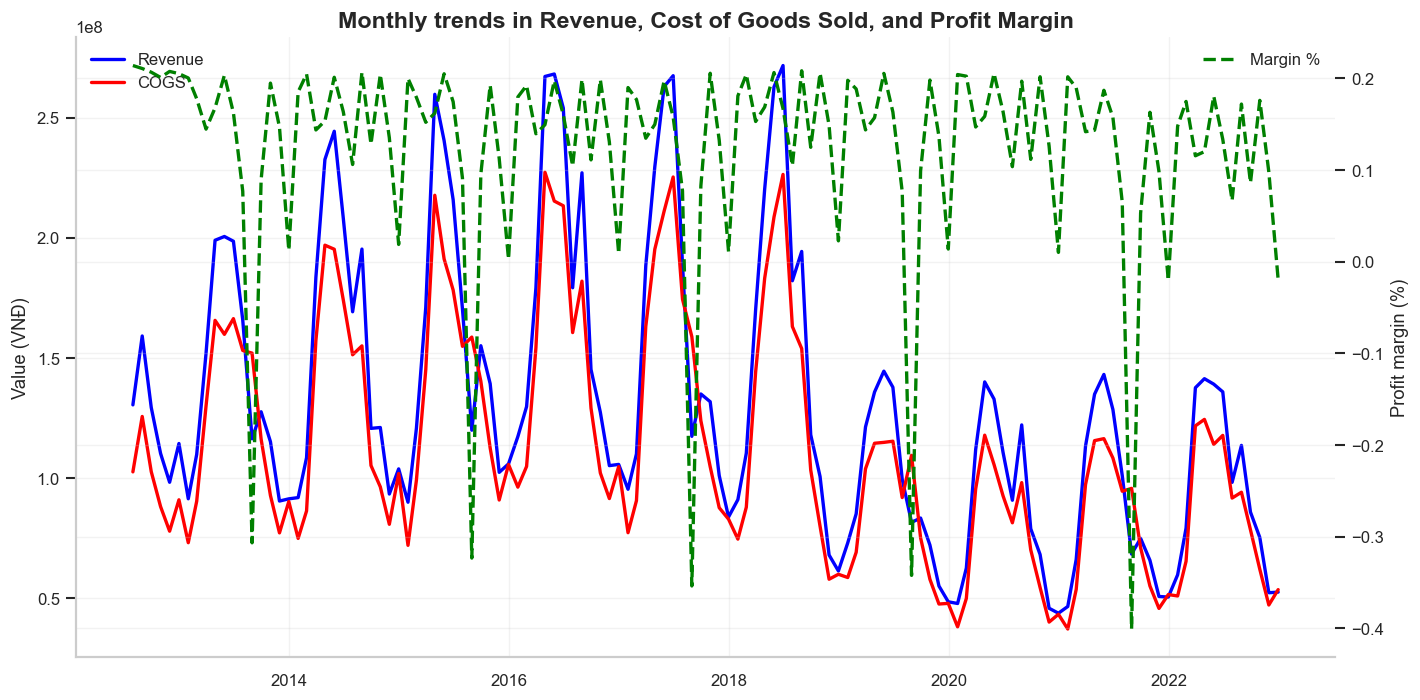

In [7]:
sales_monthly = sales.resample('ME', on='Date')[['Revenue', 'COGS']].sum()
sales_monthly['Gross_Profit'] = sales_monthly['Revenue'] - sales_monthly['COGS']
sales_monthly['Margin_Pct'] = sales_monthly['Gross_Profit'] / sales_monthly['Revenue']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(sales_monthly.index, sales_monthly['Revenue'], label='Revenue', color='b')
ax1.plot(sales_monthly.index, sales_monthly['COGS'], label='COGS', color='r')
ax1.set_ylabel('Value (VNĐ)')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(sales_monthly.index, sales_monthly['Margin_Pct'], label='Margin %', color='g', linestyle='--')
ax2.set_ylabel('Profit margin (%)')
ax2.legend(loc='upper right')

plt.title('Monthly trends in Revenue, Cost of Goods Sold, and Profit Margin')
plt.tight_layout()


Phân tích mô tả: 
- Đường Doanh thu (màu xanh) và Giá vốn (màu đỏ) lặp lại các đỉnh (peak) và đáy (trough) theo những chu kỳ rất đều đặn hàng năm. Có thể doanh nghiệp này phụ thuộc lớn vào các mùa sale hoặc mùa lễ hội.

- Từ 2014 đến 2018, quy mô các đỉnh doanh thu liên tục nhích lên. Tuy nhiên, từ 2019 đến 2022, biểu đồ cho thấy sự sụt giảm nghiêm trọng về mặt "volume" (cả đỉnh và đáy đều thấp hơn hẳn giai đoạn trước).

- Đường đứt nét màu xanh lá cho thấy Margin không hề ổn định. Thậm chí, có những tháng Margin lao dốc xuống mức âm sâu (chạm ngưỡng -30% đến -40%).

Dự đoán nguyên nhân:
- Việc biên lợi nhuận rớt xuống mức âm (tức là Tổng Giá vốn > Tổng Doanh thu) thường xảy ra vào ngay trước hoặc ngay sau các đỉnh doanh thu. Điều này chứng tỏ doanh nghiệp đang lạm dụng các chiến dịch khuyến mãi quá sâu (deep discount) hoặc phải bán xả lỗ (clearance sale) để dọn sạch hàng tồn kho.

- Về sự sụt giảm doanh số từ 2019 tới 2022 có thể do Covid-19 gây nên.

Margin trend
Trend slope: -0.000224
The Margin trend is gradually DECREASING over the years.
Average margin in the first half of the period: 12.99%
Average margin in the latter half of the period: 12.28%


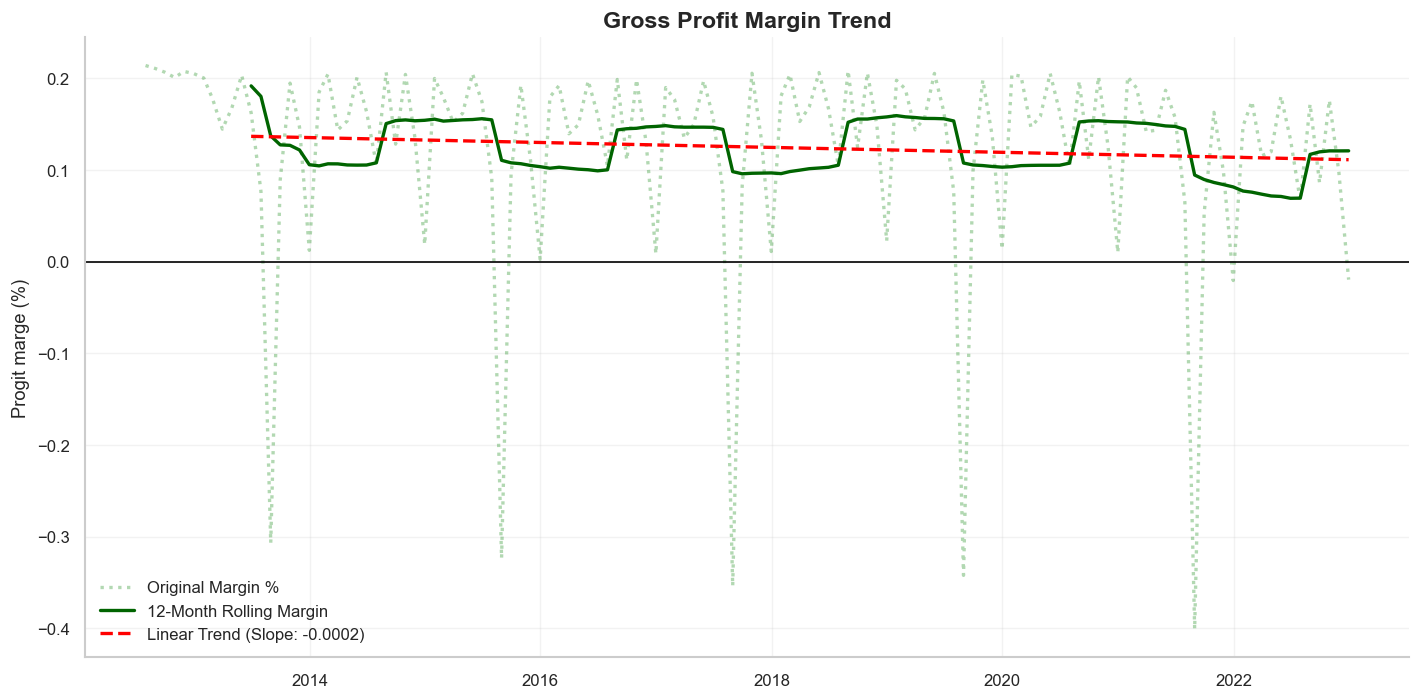

In [8]:


sales_monthly['Margin_Rolling_12M'] = sales_monthly['Margin_Pct'].rolling(window=12).mean()


valid_data = sales_monthly.dropna(subset=['Margin_Rolling_12M'])
x_time = np.arange(len(valid_data))
y_margin = valid_data['Margin_Rolling_12M'].values

slope, intercept, r_value, p_value, std_err = linregress(x_time, y_margin)

print("Margin trend")
print(f"Trend slope: {slope:.6f}")
if slope < 0:
    print("The Margin trend is gradually DECREASING over the years.")
else:
    print("The Margin trend is gradually INCREASING over the years.")

half_point = len(sales_monthly) // 2
margin_h1 = sales_monthly['Margin_Pct'].iloc[:half_point].mean() * 100
margin_h2 = sales_monthly['Margin_Pct'].iloc[half_point:].mean() * 100
print(f"Average margin in the first half of the period: {margin_h1:.2f}%")
print(f"Average margin in the latter half of the period: {margin_h2:.2f}%")


plt.figure(figsize=(12, 6))

plt.plot(sales_monthly.index, sales_monthly['Margin_Pct'], 
         color='green', linestyle=':', alpha=0.3, label='Original Margin %')

plt.plot(valid_data.index, valid_data['Margin_Rolling_12M'], 
         color='darkgreen', linewidth=2, label='12-Month Rolling Margin')

trendline = intercept + slope * x_time
plt.plot(valid_data.index, trendline, color='red', linestyle='--', linewidth=2, 
         label=f'Linear Trend (Slope: {slope:.4f})')

plt.title('Gross Profit Margin Trend')
plt.ylabel('Progit marge (%)')
plt.axhline(0, color='black', linewidth=1, linestyle='-') 
plt.legend()
plt.tight_layout()

plt.show()

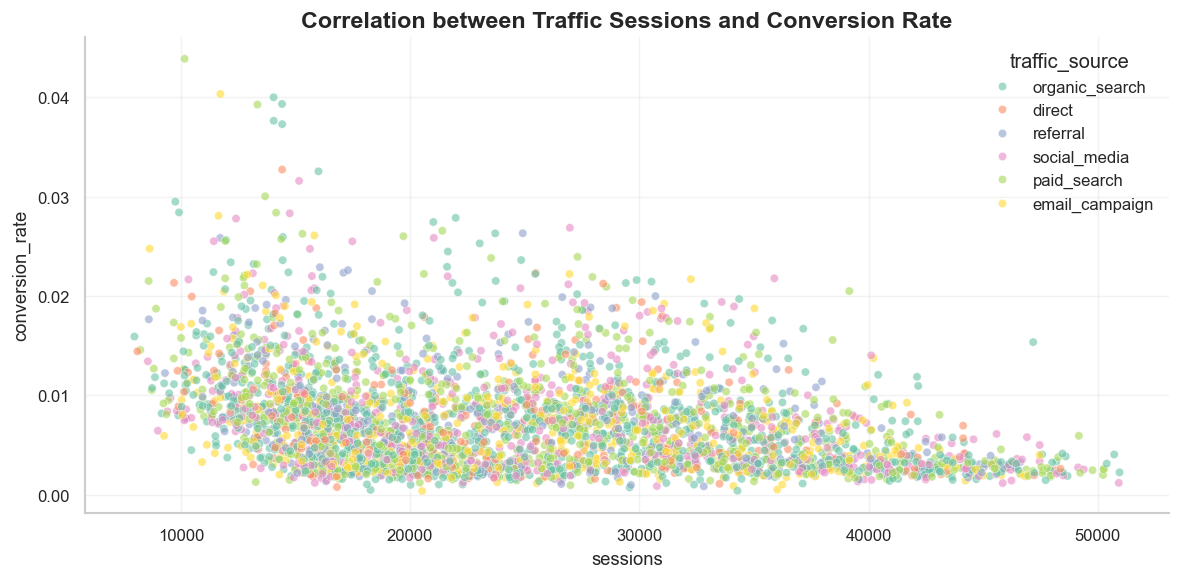

In [9]:
daily_orders = orders.groupby(orders['order_date'].dt.date)['order_id'].nunique().reset_index()
daily_orders.columns = ['date', 'total_orders']
daily_orders['date'] = pd.to_datetime(daily_orders['date'])

# Merge vs web traffic
traffic_conv = web_traffic.merge(daily_orders, on='date', how='left').fillna({'total_orders': 0})
traffic_conv['conversion_rate'] = traffic_conv['total_orders'] / traffic_conv['sessions']

plt.figure(figsize=(10, 5))
sns.scatterplot(data=traffic_conv, x='sessions', y='conversion_rate', hue='traffic_source', alpha=0.6)
plt.title('Correlation between Traffic Sessions and Conversion Rate')
plt.tight_layout()


Phân tích Mô tả:
- Biểu đồ thể hiện một hình phễu rõ rệt. Khi lượng truy cập (sessions) thấp (dưới 20.000), tỷ lệ chuyển đổi (conversion rate) dao động với biên độ rất lớn, có những ngày đạt đỉnh từ 3% đến hơn 4%.
- Khi lượng sessions tăng vọt lên mức cao (30.000 - 50.000+), tỷ lệ chuyển đổi lại bị nén chặt xuống mức rất thấp (chủ yếu dưới 1%, thậm chí tiệm cận 0).

- Bất kể nguồn truy cập là gì (organic_search, social_media, hay paid_search), khi volume đạt đỉnh, conversion rate đều chạm đáy.

Dự đoán nguyên nhân:
- Những ngày có traffic thấp thường là những luồng truy cập có "ý định mua hàng" (Purchase Intent) rất cao (ví dụ: khách quen gõ trực tiếp tên miền direct, hoặc click từ email_campaign nội bộ). Ngược lại, các đỉnh traffic 40k-50k có thể đến từ các chiến dịch quảng cáo diện rộng (Broad Reach Ads) hoặc bài đăng viral trên mạng xã hội (social_media), kéo theo một lượng lớn "window shoppers" (người chỉ vào xem cho biết chứ không có nhu cầu mua).

- Kết nối với biểu đồ tồn kho ở phần trước, khi traffic tăng đột biến, rất có thể các sản phẩm "hot" đã nhanh chóng rơi vào trạng thái Stockout. 50.000 người vào web nhưng size/màu họ cần đã hết thì tỷ lệ chuyển đổi rớt thảm hại là điều dễ hiểu.

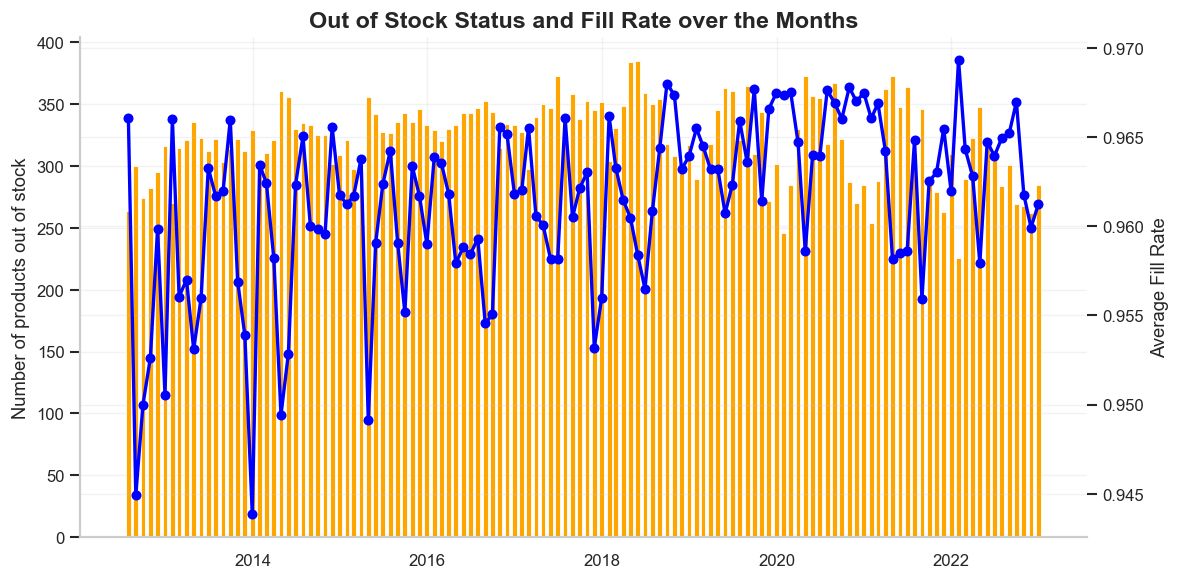

In [10]:
inv_summary = inventory.groupby('snapshot_date').agg({
    'stockout_flag': 'sum',
    'fill_rate': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(inv_summary['snapshot_date'], inv_summary['stockout_flag'], color='orange', width=20)
ax1.set_ylabel('Number of products out of stock')

ax2 = ax1.twinx() 
ax2.plot(inv_summary['snapshot_date'], inv_summary['fill_rate'], color='blue', marker='o')
ax2.set_ylabel('Average Fill Rate')

plt.title('Out of Stock Status and Fill Rate over the Months')
plt.tight_layout()


Phân tích mô tả:
- Cột màu cam (Stockout) cho thấy một thực trạng đáng báo động: Xuyên suốt từ 2014 đến 2022, tháng nào doanh nghiệp cũng có từ 250 đến gần 400 mã sản phẩm rơi vào trạng thái cháy hàng.
- Đường màu xanh dao động liên tục và mạnh mẽ trong biên độ hẹp từ khoảng 94.5% đến 97%.
- Những cú lao dốc mạnh nhất của Fill Rate (chạm đáy 0.945) thường đi kèm với việc số lượng sản phẩm stockout tăng vọt.

Dự đoán nguyên nhân:

- Sự trồi sụt liên tục của đường Fill Rate chứng tỏ khâu quản lý tồn kho đang chạy theo đuôi thị trường. Hàng bán hết -> Fill Rate giảm -> Doanh nghiệp cuống cuồng nhập bù -> Fill Rate phục hồi -> Lại bán hết. Hệ thống thiếu khả năng tự dự báo để chuẩn bị trước.
- Nhìn nhận công bằng, mức Fill Rate trung bình 95-96% là một con số tương đối tốt trong ngành bán lẻ. Việc doanh nghiệp vẫn duy trì được tỷ lệ đáp ứng đơn hàng cao dù có hàng trăm mã hết hàng chứng tỏ điều gì? Khả năng cao là họ đang dự trữ rất dồi dào các mặt hàng "Best-seller" (bán chạy nhất), nhưng lại dự báo sai lệch hoàn toàn hoặc bỏ bê các mặt hàng ngách (Long-tail products).